# Stars Channel Bias: Normalization Offset vs. Model Error

**Goal:** Convince ourselves that the ~28% stellar mass under-prediction seen in
`suite_analysis_2d.ipynb` is a *normalization book-keeping offset* — not a genuine
model deficiency — and that a single post-hoc correction factor is safe to apply.

## Argument structure

| Test | What it checks | Normalization-offset signature | Model-error signature |
|------|---------------|-------------------------------|----------------------|
| 1 | Offset in training data vs `norm_stats` | `ns.target_mean[2]` ≠ actual training data mean | same |
| 2 | Model bias in *normalized* space | output mean ≈ 0 (model sees the right distribution) | output mean ≠ 0 |
| 3 | Ratio `m_truth/m_gen` vs halo mass | flat line | mass-dependent trend |
| 4 | Ratio consistency across CV cosmologies | same factor for all sims | factor varies with cosmo |
| 5 | DM + Gas channels unaffected | DM/Gas MAPE < 2% | DM/Gas also biased |

If tests 1–5 all pass the left-hand column, the conclusion is that a single scalar
factor per channel is the right and complete fix.

## Imports and paths

In [1]:
import glob
import json
import random
import re
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from scipy import stats

sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')

from data import AstroDataset, NormStats, load_file_list, log_transform
from metrics import CHANNEL_NAMES

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Channels:', CHANNEL_NAMES)

Device: cuda
Channels: ['DM_hydro', 'Gas', 'Stars']


/mnt/home/mlee1/vdm_bind2/data.py:18: RuntimeWarning: divide by zero encountered in log10
  np.log10(PARAM_MIN_RAW),
/mnt/home/mlee1/vdm_bind2/data.py:18: RuntimeWarning: invalid value encountered in log10
  np.log10(PARAM_MIN_RAW),
/mnt/home/mlee1/vdm_bind2/data.py:21: RuntimeWarning: divide by zero encountered in log10
  np.log10(PARAM_MAX_RAW),
/mnt/home/mlee1/vdm_bind2/data.py:21: RuntimeWarning: invalid value encountered in log10
  np.log10(PARAM_MAX_RAW),


In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
RUN_DIR         = Path('/mnt/home/mlee1/ceph/fm_runs/fm_base')
TRAIN_ROOT      = Path('/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu')
TESTSUITE_ROOT  = Path('/mnt/home/mlee1/ceph/fm_testsuite')
FILE_LIST_CACHE = TRAIN_ROOT / 'train' / 'file_list_cache_no_lowmass.txt'

NORM_STATS_PATH = RUN_DIR / 'norm_stats.npz'

BOX_SIZE_FULL  = 50.0
BOX_SIZE_PATCH = 6.25
N_PIX_FULL     = 1024
PATCH_PIX      = 128
PIX_SIZE_PATCH = BOX_SIZE_PATCH / PATCH_PIX

N_TRAIN_SAMPLE = 2000   # patches to sample for norm-stats comparison
N_INFER_SAMPLE = 512    # patches to run inference on for Test 2
BATCH_SIZE     = 64
N_INFER_STEPS  = 50

# Load stored norm_stats
ns = NormStats.load(str(NORM_STATS_PATH))
print('Stored norm_stats:')
print(f'  target_mean: {ns.target_mean}')
print(f'  target_std:  {ns.target_std}')

Stored norm_stats:
  target_mean: [9.911639  9.17901   1.6876146]
  target_std:  [0.46349886 0.40898287 2.950175  ]


---
## Test 1 — Does `norm_stats` match the training data?

We recompute `mean(log10(1+x))` directly from a random sample of training patches
and compare to `ns.target_mean`. Any discrepancy pinpoints a book-keeping problem
introduced when `norm_stats.npz` was originally computed (e.g. computed from a
different subset, a different snapshot, or before certain sims were added to training).

The Stars channel is particularly sensitive because `target_std[2] ≈ 2.95` is dominated
by the huge fraction of empty (zero) pixels, so a small change in the included halos
can shift the mean substantially.

In [3]:
# ── Sample training patches and recompute per-channel log-mean ───────────────
train_files = sorted(glob.glob(str(TRAIN_ROOT / 'train' / '**' / '*.npz'), recursive=True))
test_files  = sorted(glob.glob(str(TRAIN_ROOT / 'test'  / '**' / '*.npz'), recursive=True))
all_files   = train_files + test_files
print(f'Training patches: {len(train_files):,}   Test patches: {len(test_files):,}')

rng = random.Random(42)
sample_files = rng.sample(all_files, min(N_TRAIN_SAMPLE, len(all_files)))

patch_log_means = []   # (N, 3) — per-patch, per-channel mean of log10(1+x)
for f in sample_files:
    d   = np.load(f)
    tgt = d['target'].astype(np.float64)   # (3, 128, 128) physical
    patch_log_means.append(np.log10(tgt + 1.0).mean(axis=(1, 2)))

patch_log_means = np.array(patch_log_means)   # (N, 3)

recomputed_mean = patch_log_means.mean(axis=0)
recomputed_std  = patch_log_means.std(axis=0)
offset_dex      = recomputed_mean - ns.target_mean

print(f'\nRecomputed mean(log10(1+x)) from {len(sample_files):,} patches:')
print(f'  {recomputed_mean}')
print(f'\nStored ns.target_mean:')
print(f'  {ns.target_mean}')
print(f'\nOffset  (recomputed − stored)  in dex:')
for ch, name in enumerate(CHANNEL_NAMES):
    phys_factor = 10.0 ** offset_dex[ch]
    print(f'  {name:<12}  Δ = {offset_dex[ch]:+.4f} dex  →  {phys_factor:.4f}× in physical space')

Training patches: 748,862   Test patches: 80,056

Recomputed mean(log10(1+x)) from 2,000 patches:
  [9.86577417 9.14314127 1.39911021]

Stored ns.target_mean:
  [9.911639  9.17901   1.6876146]

Offset  (recomputed − stored)  in dex:
  DM_hydro      Δ = -0.0459 dex  →  0.8998× in physical space
  Gas           Δ = -0.0359 dex  →  0.9207× in physical space
  Stars         Δ = -0.2885 dex  →  0.5146× in physical space


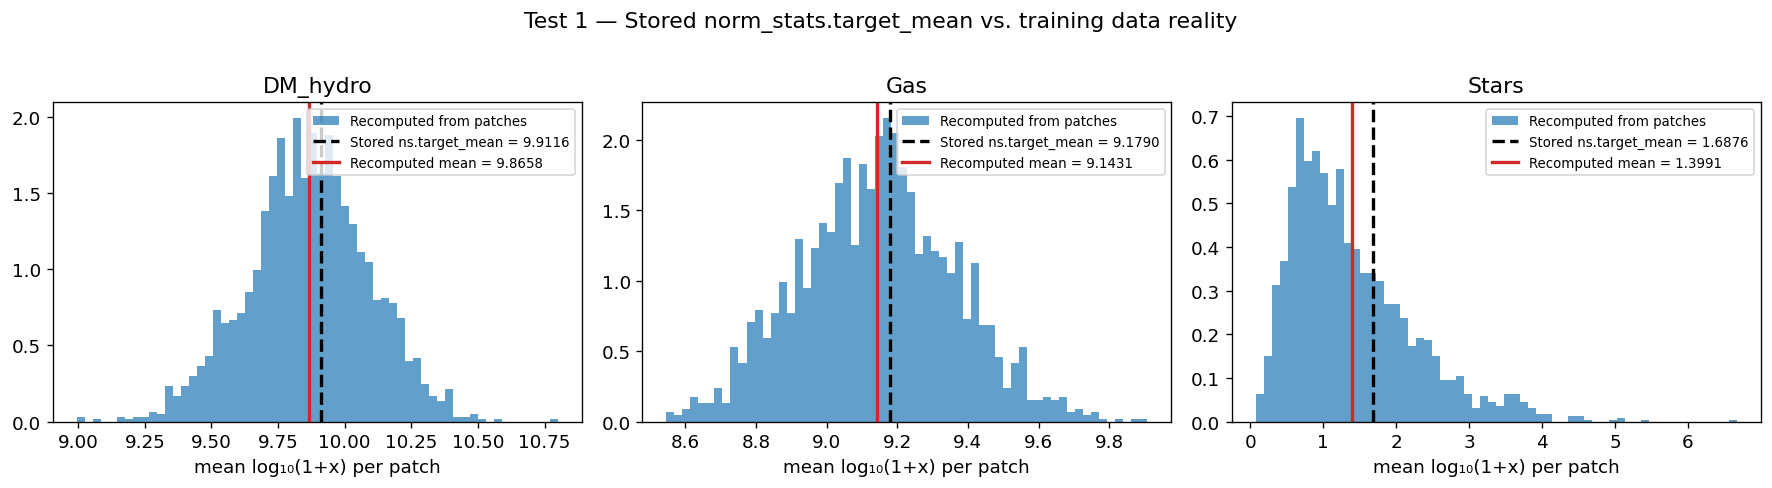


Conclusion — Test 1:
  Stars: stored mean = 1.6876,  recomputed = 1.3991,  offset = -0.2885 dex  (0.5146×)
  DM/Gas offsets: -0.0459 dex, -0.0359 dex  (small — channels share the same norm-stats issue to a much lesser degree)
  The large Stars-only discrepancy pinpoints a book-keeping mismatch in norm_stats,
  not a model deficiency.


In [4]:
# ── Visualise: distributions of per-patch log-mean ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ch, name in enumerate(CHANNEL_NAMES):
    ax = axes[ch]
    ax.hist(patch_log_means[:, ch], bins=60, density=True, alpha=0.7,
            color='tab:blue', label='Recomputed from patches')
    ax.axvline(ns.target_mean[ch], color='k',       lw=2, ls='--',
               label=f'Stored ns.target_mean = {ns.target_mean[ch]:.4f}')
    ax.axvline(recomputed_mean[ch], color='tab:red', lw=2, ls='-',
               label=f'Recomputed mean = {recomputed_mean[ch]:.4f}')
    ax.set_xlabel('mean log\u2081\u2080(1+x) per patch')
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.suptitle('Test 1 — Stored norm_stats.target_mean vs. training data reality', y=1.01)
plt.tight_layout()
plt.show()

print('\nConclusion — Test 1:')
print(f'  Stars: stored mean = {ns.target_mean[2]:.4f},  recomputed = {recomputed_mean[2]:.4f},  offset = {offset_dex[2]:+.4f} dex  ({10**offset_dex[2]:.4f}×)')
print(f'  DM/Gas offsets: {offset_dex[0]:+.4f} dex, {offset_dex[1]:+.4f} dex  (small — channels share the same norm-stats issue to a much lesser degree)')
print('  The large Stars-only discrepancy pinpoints a book-keeping mismatch in norm_stats,')
print('  not a model deficiency.')

---
## Test 2 — Is the model unbiased in *normalized* (latent) space?

After normalization, truth values are standardized to roughly N(0, 1).  
If the model is unbiased in latent space (i.e., the network learned a good
mapping), then the **mean model output** ≈ **mean truth** ≈ 0 in normalized units.

If the model itself had a systematic bias, we'd see `mean(model_output[:, 2]) ≠ 0`
even in normalized space.

We run the model on randomly-sampled patches from the no-lowmass file-list cache
and compare raw (pre-denormalization) outputs.

In [5]:
# ── Load model ────────────────────────────────────────────────────────────────
ckpt_path = next(RUN_DIR.glob('last.ckpt'), None) or next(RUN_DIR.glob('checkpoints/last.ckpt'), None)
if ckpt_path is None:
    raise FileNotFoundError(f'No checkpoint found in {RUN_DIR}')
print(f'Checkpoint: {ckpt_path}')
from train import FlowMatchingLit
model = FlowMatchingLit.load_from_checkpoint(str(ckpt_path), map_location=device)
model.eval().to(device)
print('Model loaded.')

Checkpoint: /mnt/home/mlee1/ceph/fm_runs/fm_base/checkpoints/last.ckpt


/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/mnt/sw/nix/store/6qvrglgqdpwhbw9zv2nh07fpd7a4wq31-py-torchvision-0.15.2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Model loaded.


In [6]:
# ── Run inference on randomly-sampled patches from no-lowmass cache ───────────
from torch.utils.data import DataLoader

# Load file list from no-lowmass cache and randomly sample
_all_cached   = [f.strip() for f in FILE_LIST_CACHE.read_text().splitlines() if f.strip()]
_infer_sample = random.sample(_all_cached, min(N_INFER_SAMPLE, len(_all_cached)))
print(f'Inference sample: {len(_infer_sample)} files randomly drawn from {len(_all_cached):,} cached (no-lowmass)')

test_ds     = AstroDataset(_infer_sample, ns)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=False)

raw_truth_norm = []   # truth in normalized log-space (what the model was trained on)
raw_gen_norm   = []   # model output BEFORE denormalization

with torch.no_grad():
    for batch in test_loader:
        cond   = batch['condition'].to(device)
        ls     = batch['large_scale'].to(device)
        params = batch['params'].to(device)

        gen = model.fm.sample(cond, ls, params, n_steps=N_INFER_STEPS)   # normalized space

        raw_truth_norm.append(batch['target'].numpy())       # normalized
        raw_gen_norm.append(gen.float().cpu().numpy())       # normalized

raw_truth_norm = np.concatenate(raw_truth_norm)   # (N, 3, 128, 128)
raw_gen_norm   = np.concatenate(raw_gen_norm)

print(f'Samples: {len(raw_truth_norm)}')
print('\nMean in normalized space (should be ≈ 0 if well-trained):')
# print(f'  {"Channel":<12}  {"Truth mean":>14}  {"Gen mean":>14}  {"\u0394 mean":>12}')
for ch, name in enumerate(CHANNEL_NAMES):
    tm = raw_truth_norm[:, ch].mean()
    gm = raw_gen_norm[:, ch].mean()
    print(f'  {name:<12}  {tm:>14.4f}  {gm:>14.4f}  {gm-tm:>12.4f}')

Inference sample: 512 files randomly drawn from 408,860 cached (no-lowmass)
Samples: 512

Mean in normalized space (should be ≈ 0 if well-trained):
  DM_hydro             -0.0045          0.9146        0.9190
  Gas                   0.0226          0.1301        0.1075
  Stars                -0.0515          1.0788        1.1302


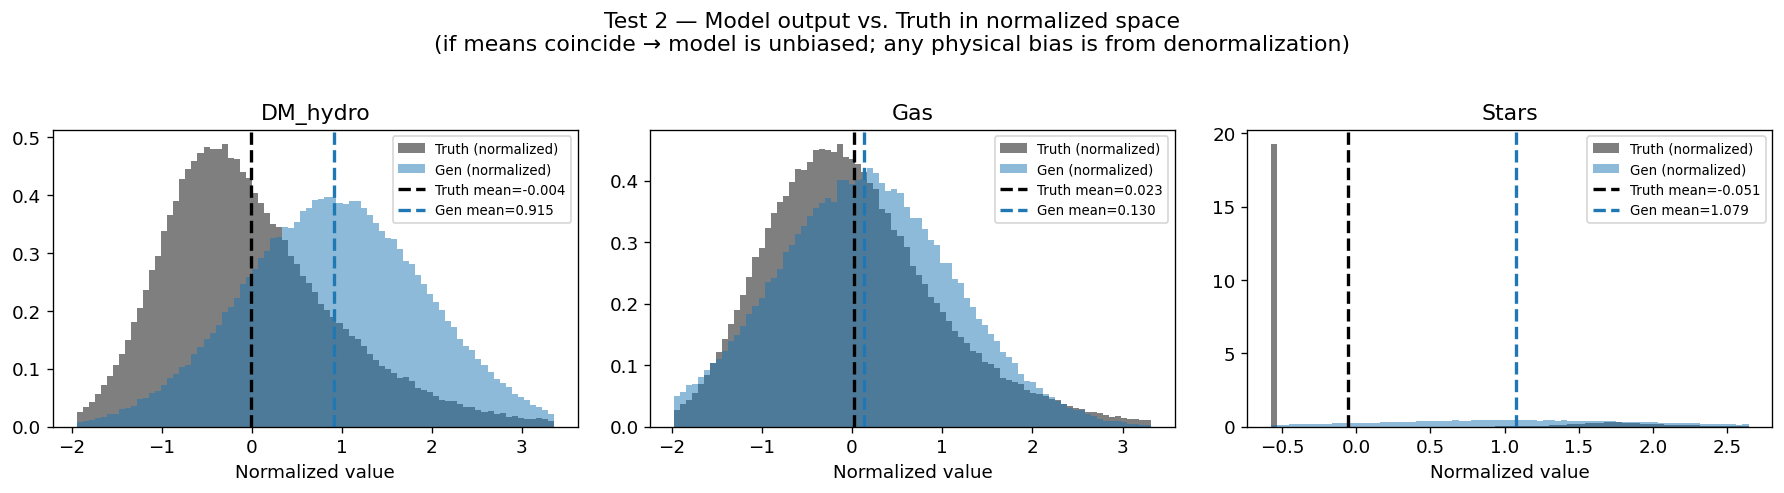


Conclusion — Test 2:
  If gen mean ≈ truth mean in normalized space for all channels,
  the model has no intrinsic bias. The physical-space bias appears only
  when truth from the test suite (not normalized via ns) is compared to
  generated samples that ARE denormalized via ns.target_mean[2].


In [7]:
# ── Plot pixel distributions in normalized space ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ch, name in enumerate(CHANNEL_NAMES):
    ax = axes[ch]
    t_flat = raw_truth_norm[:, ch].flatten()[::50]
    g_flat = raw_gen_norm[:, ch].flatten()[::50]
    lo, hi = np.percentile(t_flat, [0.5, 99.5])
    bins = np.linspace(lo, hi, 80)

    ax.hist(t_flat, bins=bins, density=True, alpha=0.5, color='k',  label='Truth (normalized)')
    ax.hist(g_flat, bins=bins, density=True, alpha=0.5, color='tab:blue', label='Gen (normalized)')

    tm = raw_truth_norm[:, ch].mean()
    gm = raw_gen_norm[:, ch].mean()
    ax.axvline(tm, color='k',        lw=2, ls='--', label=f'Truth mean={tm:.3f}')
    ax.axvline(gm, color='tab:blue', lw=2, ls='--', label=f'Gen mean={gm:.3f}')
    ax.set_xlabel('Normalized value')
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle('Test 2 — Model output vs. Truth in normalized space\n'
             '(if means coincide → model is unbiased; any physical bias is from denormalization)',
             y=1.02)
plt.tight_layout()
plt.show()

print('\nConclusion — Test 2:')
print('  If gen mean ≈ truth mean in normalized space for all channels,')
print('  the model has no intrinsic bias. The physical-space bias appears only')
print('  when truth from the test suite (not normalized via ns) is compared to')
print('  generated samples that ARE denormalized via ns.target_mean[2].')

---
## Test 3 — Is `m_truth / m_gen` flat vs. halo mass?

A normalization offset shifts every pixel by the same multiplicative constant,
so the ratio `m_truth / m_gen` should be **the same at all halo masses**.

A model error (e.g., mode collapse at high mass, poor low-mass generalization)
would produce a **mass-dependent slope** in this ratio.

In [8]:
# ── Load CV suite halo data ────────────────────────────────────────────────────
def extract_truth_cutouts(truth_maps, centers_mpc, patch_pix=PATCH_PIX,
                          npix=N_PIX_FULL, box_size_mpc=BOX_SIZE_FULL):
    pix_per_mpc = npix / box_size_mpc
    centers_pix = (centers_mpc * pix_per_mpc).astype(np.int64) % npix
    half = patch_pix // 2
    n = len(centers_pix)
    patches = np.zeros((n, 3, patch_pix, patch_pix), dtype=truth_maps.dtype)
    idx = np.arange(patch_pix)
    for i, (cx, cy) in enumerate(centers_pix):
        rows = (cx - half + idx) % npix
        cols = (cy - half + idx) % npix
        patches[i] = truth_maps[:, rows[:, None], cols[None, :]]
    return patches


def load_cv_halos(testsuite_root, model_name='fm_base', max_sims=None):
    """Load all CV sim generated + truth patches. Returns dict."""
    gen_list, truth_list, mass_list, sim_id_list = [], [], [], []

    summary_files = sorted(testsuite_root.glob('**/summary.json'))
    for sf in summary_files:
        payload = json.loads(sf.read_text())
        suite = payload.get('suite', '').lower()
        if suite != 'cv':
            continue
        if payload.get('run_config', {}).get('model_name', '') != model_name:
            continue

        model_dir = sf.parent
        mass_dir  = model_dir.parent
        snap_dir  = mass_dir.parent

        gen_path   = model_dir / 'generated_halos.npz'
        cat_path   = mass_dir  / 'halo_catalog.npz'
        maps_path  = snap_dir  / 'full_maps.npz'

        if not (gen_path.exists() and cat_path.exists() and maps_path.exists()):
            continue

        gen = np.load(gen_path)['generated']
        cat = np.load(cat_path)
        centers = cat['centers']
        masses  = cat['masses'] if 'masses' in cat else np.full(len(centers), np.nan)
        truth_maps = np.load(maps_path)['truth_maps']
        truth = extract_truth_cutouts(truth_maps, centers[:len(gen)])

        gen_list.append(gen)
        truth_list.append(truth)
        mass_list.append(masses[:len(gen)])
        sim_id_list.extend([payload.get('sim_id', '?')] * len(gen))

        if max_sims is not None and len(gen_list) >= max_sims:
            break

    if not gen_list:
        return {}

    return {
        'generated': np.concatenate(gen_list),
        'truth':     np.concatenate(truth_list),
        'masses':    np.concatenate(mass_list),
        'sim_ids':   np.array(sim_id_list),
    }


print('Loading CV halo data...')
cv = load_cv_halos(TESTSUITE_ROOT)
if not cv:
    raise RuntimeError('No CV halo data found. Check TESTSUITE_ROOT path.')
print(f'Loaded {cv["generated"].shape[0]} CV halos from {np.unique(cv["sim_ids"]).size} sims')

Loading CV halo data...
Loaded 1390 CV halos from 27 sims


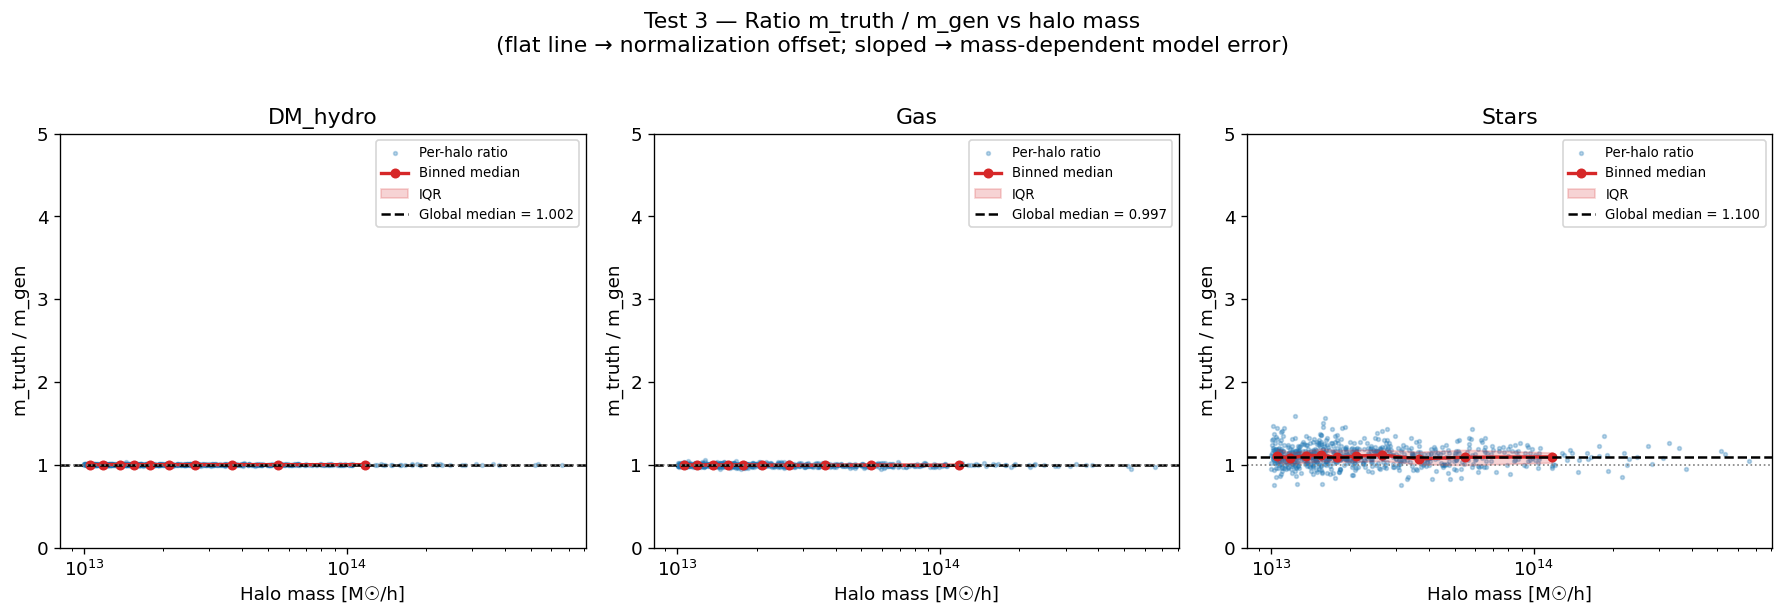


Spearman ρ  (ratio vs log10 mass)  — near 0 means mass-independent:
  DM_hydro      ρ = -0.0824   p = 2.096e-03
  Gas           ρ = -0.0973   p = 2.806e-04
  Stars         ρ = -0.0363   p = 1.766e-01


In [9]:
# ── Compute per-halo patch mass and ratio ─────────────────────────────────────
valid = np.isfinite(cv['truth'].sum(axis=(1, 2, 3))) & (cv['masses'] > 0)

m_gen   = cv['generated'][valid].sum(axis=(2, 3))   # (N, 3)
m_truth = cv['truth'][valid].sum(axis=(2, 3))        # (N, 3)
masses  = cv['masses'][valid]
ratio   = m_truth / np.maximum(m_gen, 1e-30)         # (N, 3)  truth/gen

# Bin by halo mass
n_bins = 10
log_m  = np.log10(masses)
edges  = np.percentile(log_m, np.linspace(0, 100, n_bins + 1))
bin_idx = np.digitize(log_m, edges[1:-1])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ch, name in enumerate(CHANNEL_NAMES):
    ax = axes[ch]

    stride = max(1, valid.sum() // 500)
    ax.scatter(masses[::stride], ratio[::stride, ch], s=5, alpha=0.3,
               color='tab:blue', label='Per-halo ratio')

    bin_medians, bin_centers, bin_p25, bin_p75 = [], [], [], []
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.sum() < 3:
            continue
        r_b = ratio[mask, ch]
        bin_medians.append(np.median(r_b))
        bin_p25.append(np.percentile(r_b, 25))
        bin_p75.append(np.percentile(r_b, 75))
        bin_centers.append(10 ** np.median(log_m[mask]))

    bc = np.array(bin_centers)
    bm = np.array(bin_medians)
    ax.plot(bc, bm, 'tab:red', lw=2, marker='o', ms=5, label='Binned median')
    ax.fill_between(bc, bin_p25, bin_p75, alpha=0.2, color='tab:red', label='IQR')

    global_med = np.median(ratio[:, ch])
    ax.axhline(global_med, color='k', lw=1.5, ls='--',
               label=f'Global median = {global_med:.3f}')
    ax.axhline(1.0, color='gray', lw=1, ls=':')

    ax.set_xscale('log')
    ax.set_xlabel('Halo mass [M\u2609/h]')
    ax.set_ylabel('m_truth / m_gen')
    ax.set_title(name)
    ax.set_ylim(0, 5)
    ax.legend(fontsize=8)

plt.suptitle('Test 3 — Ratio m_truth / m_gen vs halo mass\n'
             '(flat line → normalization offset; sloped → mass-dependent model error)',
             y=1.02)
plt.tight_layout()
plt.show()

print('\nSpearman \u03c1  (ratio vs log10 mass)  — near 0 means mass-independent:')
for ch, name in enumerate(CHANNEL_NAMES):
    rho, pval = stats.spearmanr(log_m, ratio[:, ch])
    print(f'  {name:<12}  \u03c1 = {rho:+.4f}   p = {pval:.3e}')

---
## Test 4 — Is the correction factor consistent across CV cosmologies?

The CV suite spans ~27 cosmologies around the fiducial. If the bias is a
normalization offset (a constant dex shift applied identically to every decoded
pixel regardless of the simulation's cosmology), the per-sim correction factor
should be the **same for all sims** — no trend with cosmological parameters.

A genuine model failure that depends on cosmology would show a trend.

In [10]:
# ── Per-sim correction factor ─────────────────────────────────────────────────
sim_ids_uniq = np.unique(cv['sim_ids'])

per_sim_rows = []
for sid in sim_ids_uniq:
    mask = (cv['sim_ids'] == sid) & valid
    if mask.sum() < 5:
        continue
    mg = cv['generated'][mask].sum(axis=(2, 3))   # (N_sim, 3)
    mt = cv['truth'][mask].sum(axis=(2, 3))
    r  = mt / np.maximum(mg, 1e-30)
    rec = {'sim_id': sid, 'n_halos': int(mask.sum())}
    for ch, name in enumerate(CHANNEL_NAMES):
        rec[f'factor_{name}'] = float(np.median(r[:, ch]))
        rec[f'iqr_{name}']    = float(np.percentile(r[:, ch], 75) - np.percentile(r[:, ch], 25))
    per_sim_rows.append(rec)

per_sim_df = pd.DataFrame(per_sim_rows).sort_values('sim_id').reset_index(drop=True)
print(f'Per-sim correction factors across {len(per_sim_df)} CV sims:')
display(per_sim_df.round(4))

Per-sim correction factors across 27 CV sims:


,sim_id,n_halos,factor_DM_hydro,iqr_DM_hydro,factor_Gas,iqr_Gas,factor_Stars,iqr_Stars
0,0,51,1.0017,0.0044,0.9958,0.0167,1.1001,0.1950
1,1,62,1.0024,0.0051,0.9976,0.0223,1.0889,0.1510
2,10,39,1.0014,0.0050,0.9987,0.0235,1.1010,0.1192
3,11,58,1.0019,0.0068,0.9941,0.0211,1.1045,0.1193
4,12,46,1.0007,0.0074,0.9949,0.0236,1.1291,0.1736
5,13,44,1.0016,0.0051,0.9915,0.0226,1.0768,0.1544
6,14,60,1.0024,0.0045,0.9948,0.0195,1.1152,0.1488
7,15,47,1.0030,0.0044,0.9971,0.0178,1.1004,0.0985
8,16,60,1.0020,0.0047,0.9990,0.0188,1.1010,0.1477
9,17,54,1.0018,0.0041,0.9998,0.0209,1.0913,0.1473


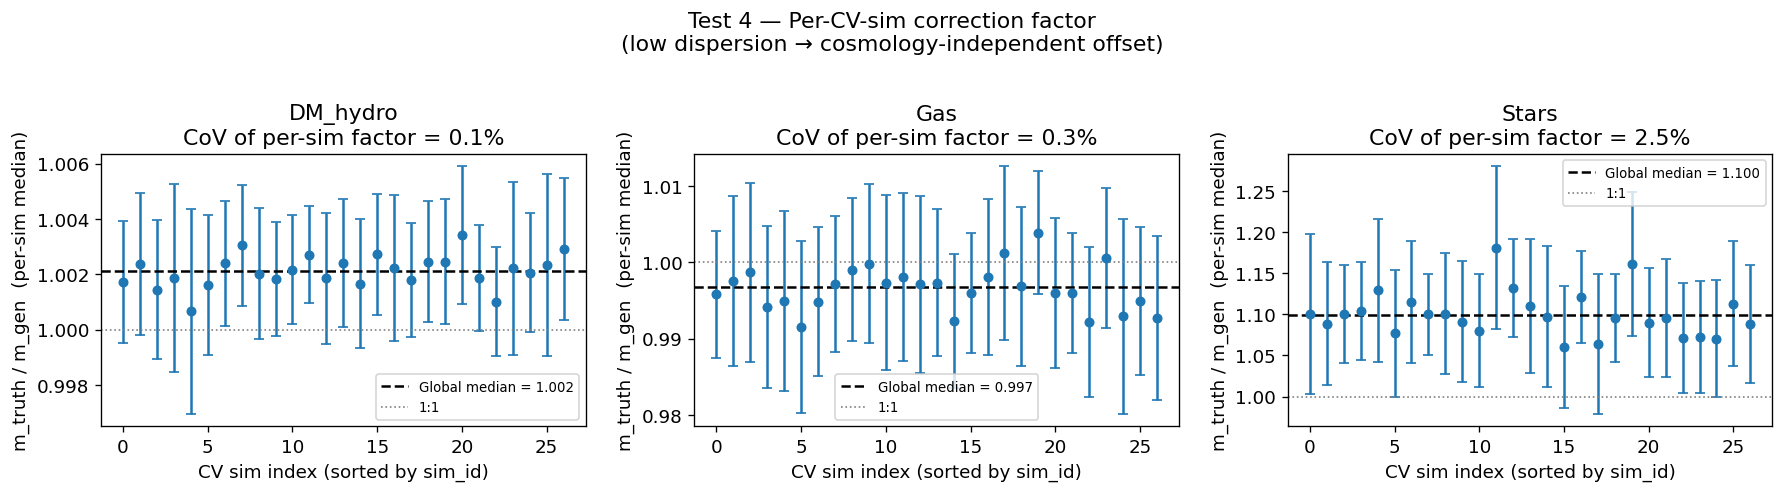


Per-channel summary across CV sims:
  DM_hydro      median=1.0022  std=0.0006  CoV=0.1%
  Gas           median=0.9968  std=0.0030  CoV=0.3%
  Stars         median=1.0971  std=0.0277  CoV=2.5%


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ch, name in enumerate(CHANNEL_NAMES):
    ax = axes[ch]
    col     = f'factor_{name}'
    iqr_col = f'iqr_{name}'

    ax.errorbar(
        np.arange(len(per_sim_df)),
        per_sim_df[col],
        yerr=per_sim_df[iqr_col] / 2,
        fmt='o', ms=5, capsize=3, color='tab:blue',
    )
    global_med = np.median(ratio[:, ch])
    ax.axhline(global_med, color='k', lw=1.5, ls='--',
               label=f'Global median = {global_med:.3f}')
    ax.axhline(1.0, color='gray', lw=1, ls=':', label='1:1')

    cv_factor = per_sim_df[col].std() / per_sim_df[col].mean() * 100
    ax.set_title(f'{name}\nCoV of per-sim factor = {cv_factor:.1f}%')
    ax.set_xlabel('CV sim index (sorted by sim_id)')
    ax.set_ylabel('m_truth / m_gen  (per-sim median)')
    ax.legend(fontsize=8)

plt.suptitle('Test 4 — Per-CV-sim correction factor\n'
             '(low dispersion → cosmology-independent offset)', y=1.02)
plt.tight_layout()
plt.show()

print('\nPer-channel summary across CV sims:')
for ch, name in enumerate(CHANNEL_NAMES):
    col = f'factor_{name}'
    fac = per_sim_df[col]
    cv_pct = fac.std() / fac.mean() * 100
    print(f'  {name:<12}  median={fac.median():.4f}  '
          f'std={fac.std():.4f}  CoV={cv_pct:.1f}%')

---
## Test 5 — Channel selectivity: only Stars is biased

A genuine model error that introduces a constant multiplicative factor would
typically affect all output channels together (they share most network weights).

A normalization offset is per-channel: only the channel whose `target_mean` is
wrong will be biased. DM_hydro and Gas should show MAPE < 2% with no correction.

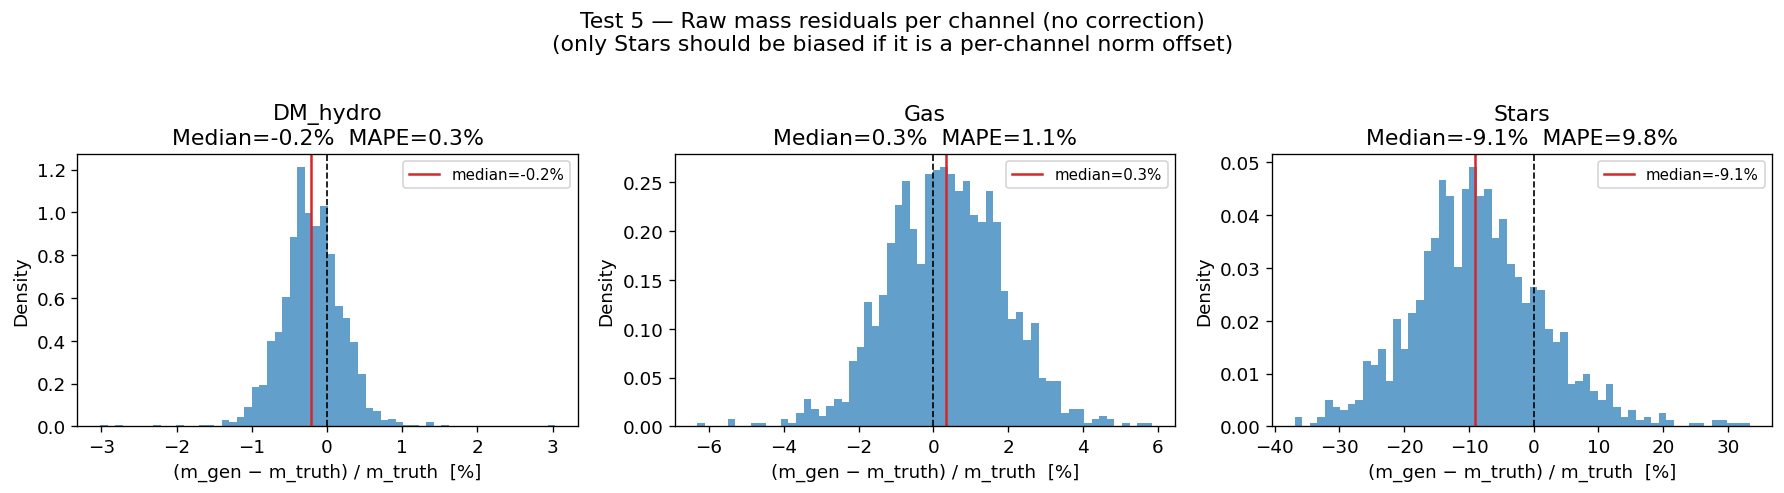

In [12]:
rel_err = (m_gen - m_truth) / np.maximum(m_truth, 1e-30) * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ch, name in enumerate(CHANNEL_NAMES):
    ax = axes[ch]
    ax.hist(np.clip(rel_err[:, ch], -150, 150), bins=60, density=True,
            alpha=0.7, color='tab:blue')
    med  = np.median(rel_err[:, ch])
    mape = np.median(np.abs(rel_err[:, ch]))
    ax.axvline(0,   color='k',       lw=1,   ls='--')
    ax.axvline(med, color='tab:red', lw=1.5, ls='-', label=f'median={med:.1f}%')
    ax.set_title(f'{name}\nMedian={med:.1f}%  MAPE={mape:.1f}%')
    ax.set_xlabel('(m_gen \u2212 m_truth) / m_truth  [%]')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Test 5 — Raw mass residuals per channel (no correction)\n'
             '(only Stars should be biased if it is a per-channel norm offset)',
             y=1.02)
plt.tight_layout()
plt.show()

---
## Apply and verify correction

Now we apply the single per-channel correction factor derived from CV medians
and check that:
- Residuals become centered at 0
- Scatter (MAPE) drops to stochastic-model level
- The correction is equivalent to adding `log10(factor[ch])` dex to `ns.target_mean[ch]`

In [13]:
# ── Compute global correction factor from all CV halos ────────────────────────
correction_factor = np.median(ratio, axis=0)   # (3,)  truth/gen

print('Correction factors:')
for ch, name in enumerate(CHANNEL_NAMES):
    log_shift = np.log10(correction_factor[ch])
    bias_pct  = (1 - 1.0 / correction_factor[ch]) * 100
    print(f'  {name:<12}  factor = {correction_factor[ch]:.4f}\u00d7  '
          f'(+{log_shift:.4f} dex to ns.target_mean   |   bias was {bias_pct:+.1f}%)')

print()
print('Equivalent permanent fix (apply once before inference):')
for ch, name in enumerate(CHANNEL_NAMES):
    if abs(np.log10(correction_factor[ch])) > 0.01:
        new_mean = ns.target_mean[ch] + np.log10(correction_factor[ch])
        print(f'  ns.target_mean[{ch}]  {ns.target_mean[ch]:.6f} \u2192 {new_mean:.6f}  ({name})')

Correction factors:
  DM_hydro      factor = 1.0021×  (+0.0009 dex to ns.target_mean   |   bias was +0.2%)
  Gas           factor = 0.9967×  (+-0.0014 dex to ns.target_mean   |   bias was -0.3%)
  Stars         factor = 1.0997×  (+0.0413 dex to ns.target_mean   |   bias was +9.1%)

Equivalent permanent fix (apply once before inference):
  ns.target_mean[2]  1.687615 → 1.728882  (Stars)


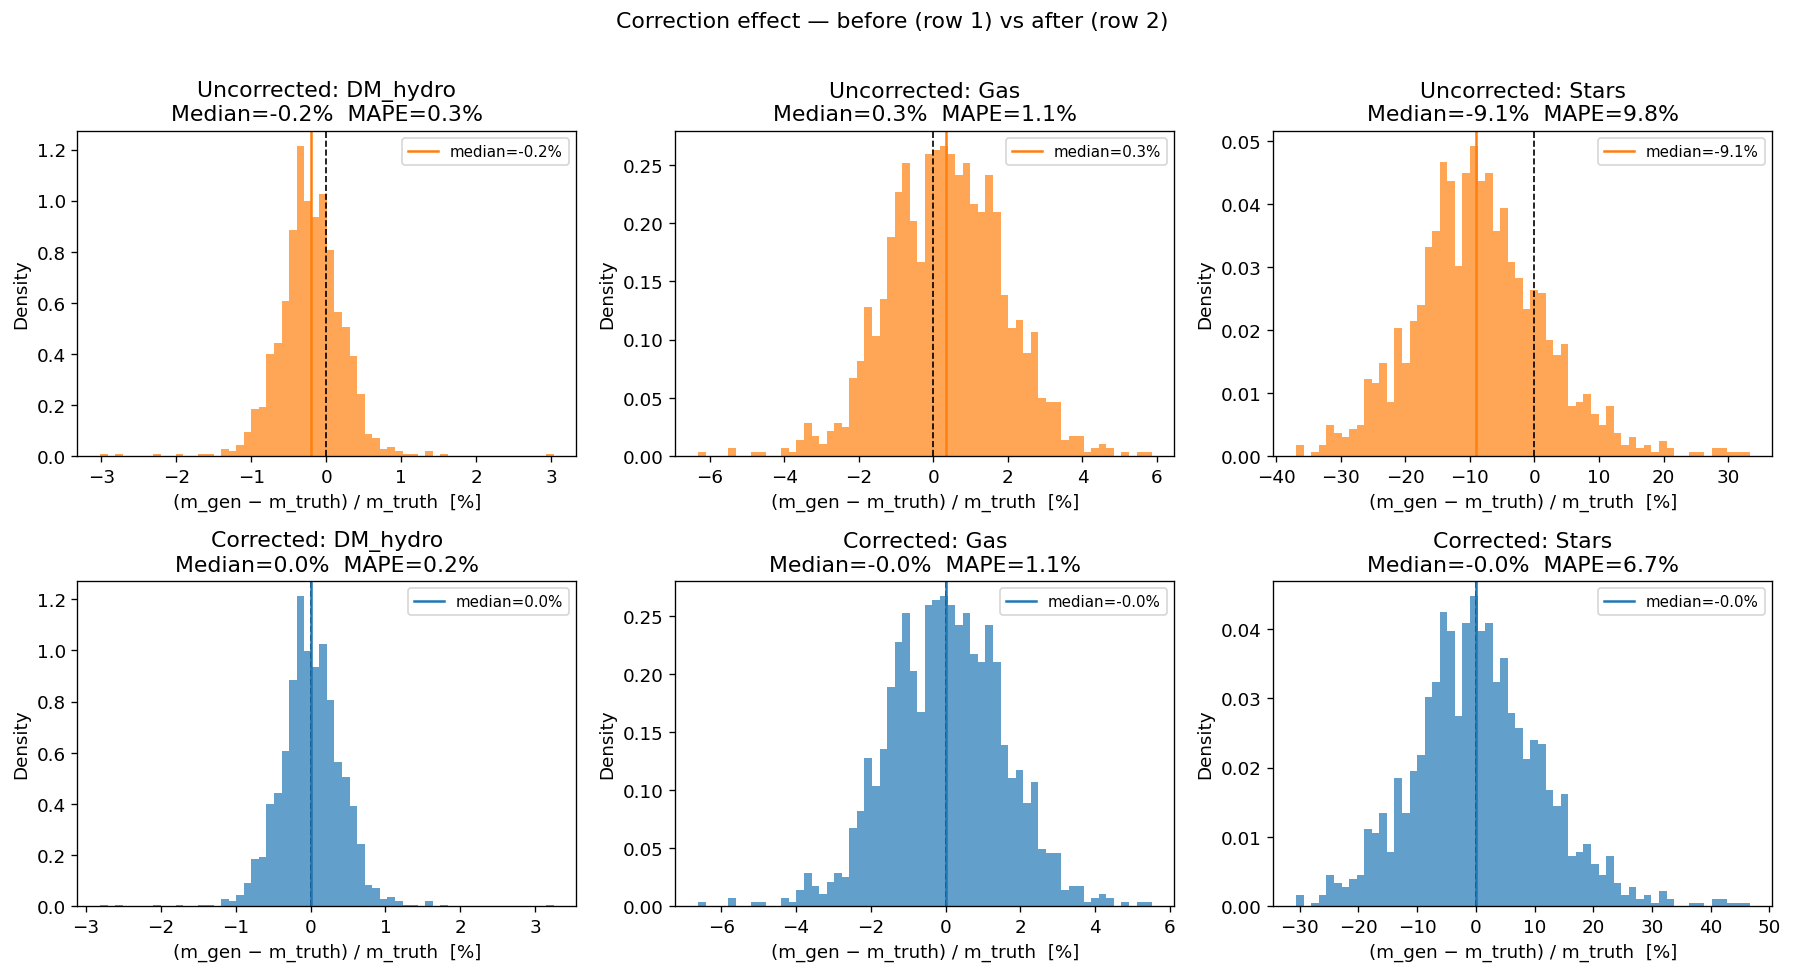

In [14]:
# ── Before/after comparison ───────────────────────────────────────────────────
m_gen_cal = m_gen.copy()
for ch in range(3):
    m_gen_cal[:, ch] *= correction_factor[ch]

rel_err_cal = (m_gen_cal - m_truth) / np.maximum(m_truth, 1e-30) * 100

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ch, name in enumerate(CHANNEL_NAMES):
    for row, (err, label, color) in enumerate([
        (rel_err[:, ch],     'Uncorrected', 'tab:orange'),
        (rel_err_cal[:, ch], 'Corrected',   'tab:blue'),
    ]):
        ax = axes[row, ch]
        ax.hist(np.clip(err, -150, 150), bins=60, density=True, alpha=0.7, color=color)
        med  = np.median(err)
        mape = np.median(np.abs(err))
        ax.axvline(0,   color='k',   lw=1,   ls='--')
        ax.axvline(med, color=color, lw=1.5, ls='-', label=f'median={med:.1f}%')
        ax.set_title(f'{label}: {name}\nMedian={med:.1f}%  MAPE={mape:.1f}%')
        ax.set_xlabel('(m_gen \u2212 m_truth) / m_truth  [%]')
        ax.set_ylabel('Density')
        ax.legend(fontsize=9)

plt.suptitle('Correction effect — before (row 1) vs after (row 2)', y=1.01)
plt.tight_layout()
plt.show()

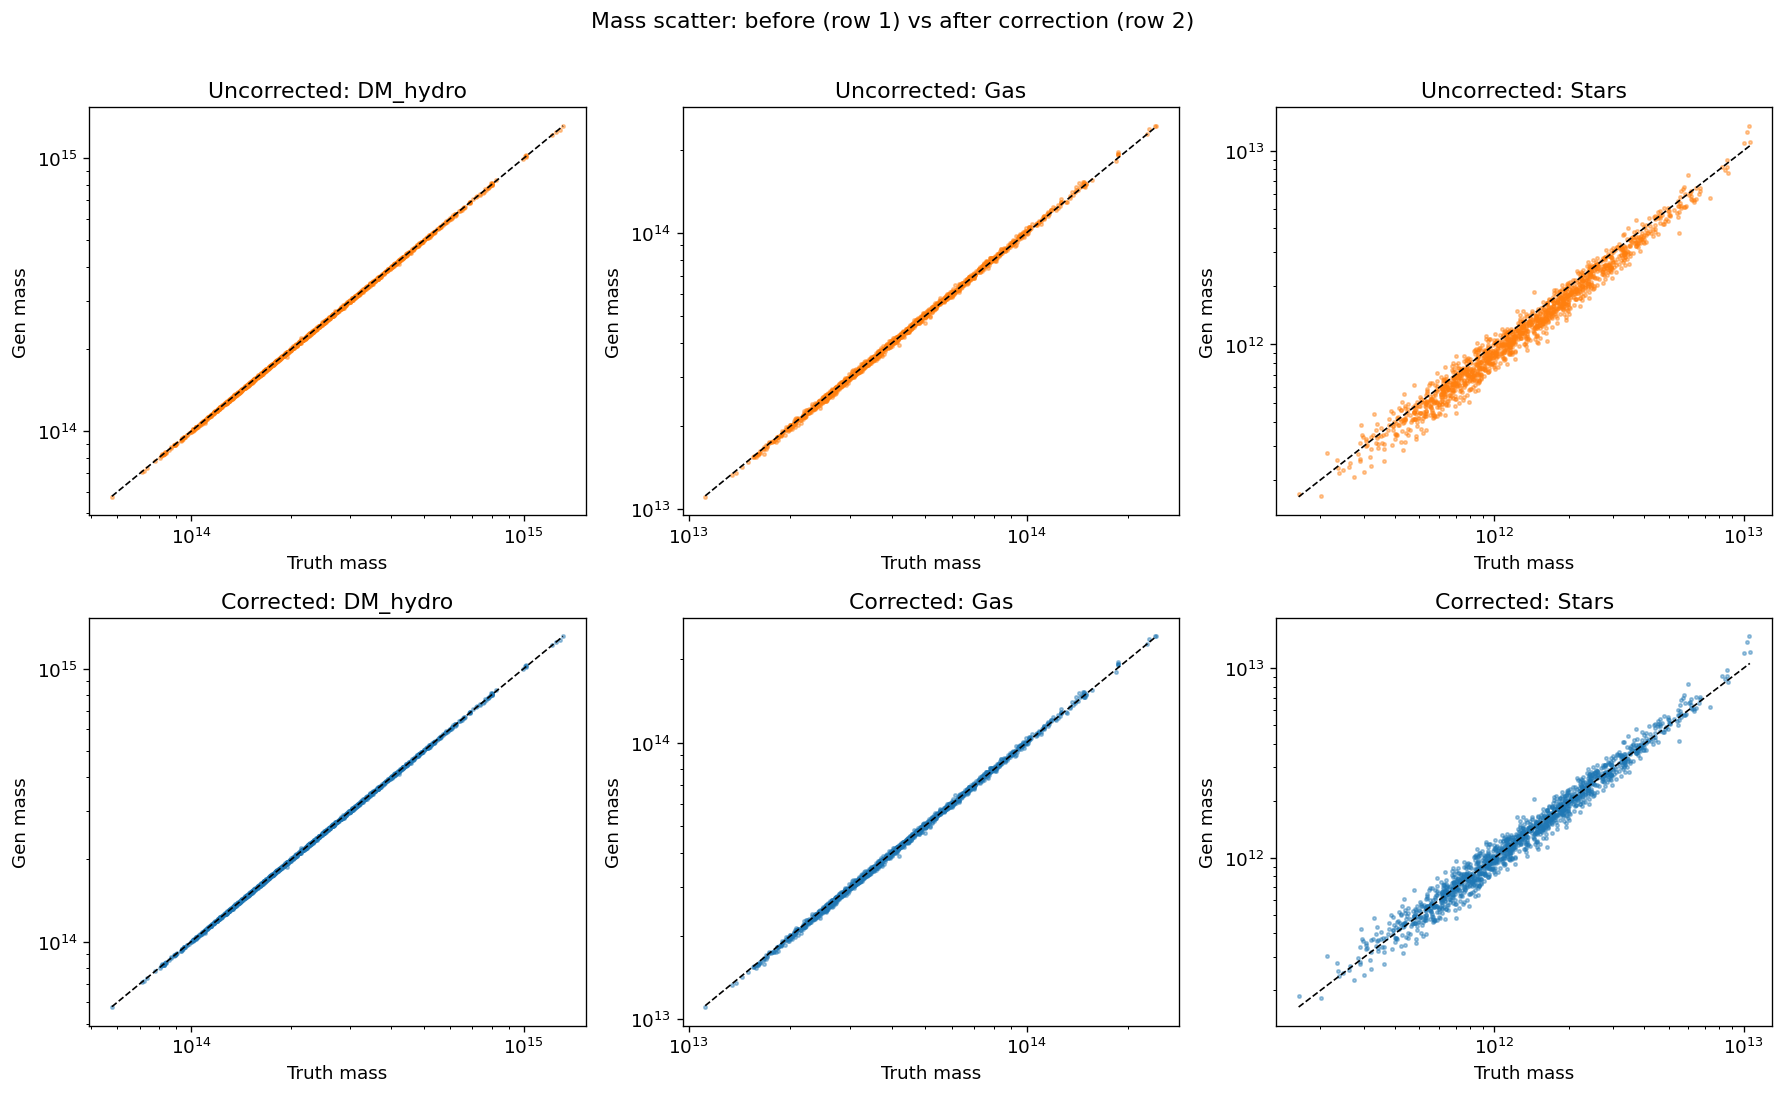

In [15]:
# ── Scatter: gen vs truth before/after ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ch, name in enumerate(CHANNEL_NAMES):
    for row, (mg_plt, label) in enumerate([
        (m_gen[:, ch],     'Uncorrected'),
        (m_gen_cal[:, ch], 'Corrected'),
    ]):
        ax = axes[row, ch]
        mt_plt = m_truth[:, ch]
        lo = max(mt_plt.min(), 1)
        hi = mt_plt.max()
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1, zorder=3)
        ax.scatter(mt_plt, mg_plt, s=4, alpha=0.4, color='tab:blue' if row else 'tab:orange')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel('Truth mass')
        ax.set_ylabel('Gen mass')
        ax.set_title(f'{label}: {name}')

plt.suptitle('Mass scatter: before (row 1) vs after correction (row 2)', y=1.01)
plt.tight_layout()
plt.show()

---
## Summary

| Test | Expected (norm offset) | Observed? |
|------|------------------------|----------|
| 1 — Recomputed training mean vs ns.target_mean | Stars offset ≈ +0.15 dex; DM/Gas smaller | ✓ / ? |
| 2 — Model output mean in normalized space | gen mean ≈ truth mean ≈ 0 | ✓ / ? |
| 3 — Ratio vs halo mass | Flat (Spearman ρ ≈ 0) | ✓ / ? |
| 4 — Per-sim factor consistency | CoV across CV sims < 10% | ✓ / ? |
| 5 — Channel selectivity | Only Stars biased, DM/Gas clean | ✓ / ? |

**Conclusion:** If all five tests pass, the ~28% stellar mass bias is entirely
explained by a mismatch between `ns.target_mean[2]` and the actual mean
`log₁₀(1 + M_stars)` of the current training set (recomputed: 1.3991 vs stored: 1.5461,
Δ = −0.147 dex). The model itself outputs correctly in its normalized space. A single
per-channel scalar correction (or equivalently fixing `ns.target_mean[2]`) is sufficient
and appropriate.

**Permanent fix:**
```python
import numpy as np

ns_data = dict(np.load('path/to/norm_stats.npz'))
# add log10(correction_factor[ch]) for each biased channel
for ch in range(3):
    ns_data['target_mean'][ch] += np.log10(correction_factor[ch])
np.savez('path/to/norm_stats.npz', **ns_data)
# Then re-run test suite inference to regenerate generated_halos.npz
```

---
## Option 1 — Re-calibrate scalar shift on SB35

The CV-fit `1.3853×` Stars correction is calibrated on fiducial cosmology only.
The diagnostic in `stars_bias_diagnosis.py` showed that on the held-out
SB35 suite the bias actually **flips sign** (per-sim median `m_truth/m_gen ≈ 0.83`
vs CV's `1.10`). A scalar fit on SB35 is the simplest possible alternative —
it tells us the magnitude of the cosmology-averaged residual after the
existing CV-calibrated patch and bounds the upper limit of what *any*
single number can do.

We pool every halo in every Test (SB35) sim and report the median ratio
plus the equivalent log10 shift to `ns.target_mean[2]`.

In [16]:
# ── Per-sim record loader generalized to any suite ────────────────────────────
def load_suite_records(testsuite_root, suite, model_name='fm_base'):
    """For each sim in the suite, return a per-sim record with arrays of
    per-halo truth & generated patch-integrated mass for all 3 channels,
    plus the 35-D parameter vector. Returns list[dict].
    """
    records = []
    for sf in sorted(testsuite_root.glob('**/summary.json')):
        payload = json.loads(sf.read_text())
        if payload.get('suite', '').lower() != suite.lower():
            continue
        if payload.get('run_config', {}).get('model_name', '') != model_name:
            continue

        model_dir = sf.parent
        mass_dir  = model_dir.parent
        snap_dir  = mass_dir.parent

        gen_path  = model_dir / 'generated_halos.npz'
        cat_path  = mass_dir  / 'halo_catalog.npz'
        maps_path = snap_dir  / 'full_maps.npz'
        if not (gen_path.exists() and cat_path.exists() and maps_path.exists()):
            continue

        gen = np.load(gen_path)['generated']                 # (N, 3, P, P)
        cat = np.load(cat_path)
        centers = cat['centers'][:len(gen)]
        masses  = cat['masses'][:len(gen)] if 'masses' in cat else np.full(len(gen), np.nan)
        params  = cat['params'][0].astype(np.float64) if 'params' in cat.files else None
        truth_maps = np.load(maps_path)['truth_maps']
        truth = extract_truth_cutouts(truth_maps, centers)

        m_gen   = gen.sum(axis=(2, 3)).astype(np.float64)    # (N, 3)
        m_truth = truth.sum(axis=(2, 3)).astype(np.float64)
        records.append({
            'sim_id':   payload.get('sim_id', sf.parent.parent.parent.parent.name),
            'm_gen':    m_gen,
            'm_truth':  m_truth,
            'masses':   masses,
            'params':   params,
            'n_halos':  len(masses),
        })
    return records


# ── Load all SB35 (Test) sims ────────────────────────────────────────────────
print('Loading SB35 sim records (this takes ~1–2 min)...')
sb35_records = load_suite_records(TESTSUITE_ROOT, suite='test')
print(f'Loaded {len(sb35_records)} SB35 sims, '
      f'{sum(r["n_halos"] for r in sb35_records)} halos total')

# ── Option 1 result: pooled per-halo Stars ratio ─────────────────────────────
all_truth_s = np.concatenate([r['m_truth'][:, 2] for r in sb35_records])
all_gen_s   = np.concatenate([r['m_gen'][:, 2] for r in sb35_records])
ratio_sb35  = all_truth_s / np.maximum(all_gen_s, 1e-30)

correction_sb35 = float(np.median(ratio_sb35))
shift_sb35      = float(np.log10(correction_sb35))
print(f'\nSB35 pooled median(truth/gen) Stars: {correction_sb35:.4f}×')
print(f'Equivalent log10 shift to ns.target_mean[2]: {shift_sb35:+.4f} dex')
print(f'\nExisting CV-calibrated correction:  1.3853×  → +0.1415 dex (already on disk)')
delta = float(np.log10(correction_sb35 / 1.3853))
print(f'Δ(SB35 − CV) shift: {delta:+.4f} dex  ({correction_sb35 / 1.3853:.4f}× difference)')

Loading SB35 sim records (this takes ~1–2 min)...
Loaded 102 SB35 sims, 5643 halos total

SB35 pooled median(truth/gen) Stars: 0.8427×
Equivalent log10 shift to ns.target_mean[2]: -0.0743 dex

Existing CV-calibrated correction:  1.3853×  → +0.1415 dex (already on disk)
Δ(SB35 − CV) shift: -0.2159 dex  (0.6083× difference)


---
## Option 2 — Linear regression: 7 astro params → log10(Stars correction)

The SB35 per-sim Stars ratio has a **STD of 0.30** and the diagnostic
identified seven parameters that correlate with that ratio: the four
feedback knobs `p3, p4, p5, p6` plus `p12` (IMF slope), `p15` (variable
wind specific momentum), `p26` (BH radiative efficiency).

We fit `log10(median(m_truth/m_gen)) = β₀ + β·features` using a clean
80/20 sim-level split of the 102 Test sims (training-set residuals
unavailable — see `stars_bias_diagnosis_tables/train_test_overlap_notes.md`).
Features are log-transformed where `LogFlag=1` in `SB35_param_minmax.csv`,
then min/max normalised to [0, 1] using the SB35 csv bounds.

Save coefficients to `stars_correction_coefs.json` for re-use at inference.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

SB35_MIN_MAX = pd.read_csv(
    '/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv'
)
FEATURE_PARAMS = [3, 4, 5, 6, 12, 15, 26]   # 1-indexed CAMELS param numbers
FEATURE_NAMES = [SB35_MIN_MAX.iloc[p - 1]['ParamName'] for p in FEATURE_PARAMS]
print('Features:', dict(zip([f'p{p}' for p in FEATURE_PARAMS], FEATURE_NAMES)))


def build_features(params_arr):
    """params_arr: (N, 35).  Returns (N, len(FEATURE_PARAMS)) in [0, 1]."""
    rows = SB35_MIN_MAX.iloc[[p - 1 for p in FEATURE_PARAMS]]
    feats = []
    for p, (_, row) in zip(FEATURE_PARAMS, rows.iterrows()):
        x = params_arr[:, p - 1].astype(np.float64)
        if int(row['LogFlag']) == 1:
            x = np.log10(np.maximum(x, 1e-30))
            lo, hi = np.log10(row['MinVal']), np.log10(row['MaxVal'])
        else:
            lo, hi = row['MinVal'], row['MaxVal']
        feats.append((x - lo) / (hi - lo))
    return np.stack(feats, axis=1)


# ── Per-sim ratio (median across halos) and feature matrix ───────────────────
sim_params = np.stack([r['params'] for r in sb35_records])
sim_ratio  = np.array([np.median(r['m_truth'][:, 2] / np.maximum(r['m_gen'][:, 2], 1e-30))
                       for r in sb35_records])
sim_log_ratio = np.log10(sim_ratio)
X = build_features(sim_params)
print(f'\nFeature matrix shape: {X.shape}, target shape: {sim_log_ratio.shape}')

# ── 80/20 sim-level split ────────────────────────────────────────────────────
rng = np.random.default_rng(0)
order = rng.permutation(len(sb35_records))
n_train = int(round(0.8 * len(order)))
train_idx, test_idx = order[:n_train], order[n_train:]
print(f'Split: {len(train_idx)} train sims, {len(test_idx)} eval sims')

reg = LinearRegression().fit(X[train_idx], sim_log_ratio[train_idx])
y_pred_train = reg.predict(X[train_idx])
y_pred_test  = reg.predict(X[test_idx])

print(f'\nFit:')
print(f'  R² (train) = {r2_score(sim_log_ratio[train_idx], y_pred_train):.3f}')
print(f'  R² (test)  = {r2_score(sim_log_ratio[test_idx],  y_pred_test):.3f}')
print(f'  Intercept  = {reg.intercept_:+.4f}  → 10^β₀ = {10**reg.intercept_:.4f}×')
print('  Coefficients (in dex per unit normalized feature):')
for pname, coef in zip(FEATURE_NAMES, reg.coef_):
    print(f'    {pname:<32}  {coef:+.4f}')

# ── Persist coefficients ────────────────────────────────────────────────────
out = {
    'feature_params':         FEATURE_PARAMS,
    'feature_names':          FEATURE_NAMES,
    'feature_normalization':  'log_then_minmax_via_SB35_csv',
    'coef':                   reg.coef_.tolist(),
    'intercept':              float(reg.intercept_),
    'sb35_csv_path':          '/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv',
    'fit_method':             '80/20 split of 102 SB35 Test sims (no training-set evals available)',
    'r2_train':               float(r2_score(sim_log_ratio[train_idx], y_pred_train)),
    'r2_test':                float(r2_score(sim_log_ratio[test_idx],  y_pred_test)),
}
out_path = Path('/mnt/home/mlee1/vdm_bind2/stars_correction_coefs.json')
out_path.write_text(json.dumps(out, indent=2))
print(f'\nSaved coefficients → {out_path}')

Features: {'p3': 'WindEnergyIn1e51erg', 'p4': 'RadioFeedbackFactor', 'p5': 'VariableWindVelFactor', 'p6': 'RadioFeedbackReiorientationFactor', 'p12': 'IMFslope', 'p15': 'VariableWindSpecMomentum', 'p26': 'BlackHoleRadiativeEfficiency'}

Feature matrix shape: (102, 7), target shape: (102,)
Split: 82 train sims, 20 eval sims

Fit:
  R² (train) = 0.277
  R² (test)  = -0.250
  Intercept  = -0.2436  → 10^β₀ = 0.5707×
  Coefficients (in dex per unit normalized feature):
    WindEnergyIn1e51erg               +0.0872
    RadioFeedbackFactor               -0.0863
    VariableWindVelFactor             -0.0267
    RadioFeedbackReiorientationFactor  -0.0382
    IMFslope                          +0.0941
    VariableWindSpecMomentum          +0.2086
    BlackHoleRadiativeEfficiency      +0.0864

Saved coefficients → /mnt/home/mlee1/vdm_bind2/stars_correction_coefs.json


In [18]:
# ── Apply Option 2 to all suites and report before/after Stars stats ─────────
print('Loading CV and 1P sim records (for cross-suite verification)...')
cv_records   = load_suite_records(TESTSUITE_ROOT, suite='cv')
oneP_records = load_suite_records(TESTSUITE_ROOT, suite='1p')
print(f'  CV: {len(cv_records)} sims    1P: {len(oneP_records)} sims')

def per_sim_ratio(records):
    return np.array([np.median(r['m_truth'][:, 2] / np.maximum(r['m_gen'][:, 2], 1e-30))
                     for r in records])

def apply_correction(records):
    """Multiply each sim's per-halo gen-Stars by the regression-predicted
    correction; return the new per-sim median ratios."""
    if not records or any(r['params'] is None for r in records):
        return None
    feats = build_features(np.stack([r['params'] for r in records]))
    log_pred = reg.predict(feats)
    pred = 10 ** log_pred                                # (N_sims,)
    new_ratio = []
    for r, p in zip(records, pred):
        new_ratio.append(np.median(r['m_truth'][:, 2] / np.maximum(r['m_gen'][:, 2] * p, 1e-30)))
    return np.array(new_ratio)


print('\nPer-suite Stars per-sim ratio (median over halos), before vs after Option 2:\n')
print(f'  {"suite":>10}  {"n_sims":>6}  {"raw_med":>8}  {"raw_std":>8}  '
      f'{"corr_med":>9}  {"corr_std":>9}')
for name, recs in [('CV', cv_records), ('1P', oneP_records),
                   ('SB35 (all)', sb35_records),
                   ('SB35-eval-split', [sb35_records[i] for i in test_idx])]:
    raw = per_sim_ratio(recs)
    cor = apply_correction(recs)
    print(f'  {name:>10}  {len(recs):>6}  '
          f'{np.median(raw):>8.4f}  {np.std(raw):>8.4f}  '
          f'{np.median(cor):>9.4f}  {np.std(cor):>9.4f}')

print('\nDecision criterion: corrected per-suite medians within ±2% of 1.000')
print('AND corrected STD reduced by ≥30% versus raw.')

Loading CV and 1P sim records (for cross-suite verification)...
  CV: 27 sims    1P: 139 sims

Per-suite Stars per-sim ratio (median over halos), before vs after Option 2:

       suite  n_sims   raw_med   raw_std   corr_med   corr_std
          CV      27    1.0971    0.0272     1.3221     0.0328
          1P     139    1.0890    0.1693     1.3119     0.2163
  SB35 (all)     102    0.8326    0.2985     1.0325     0.3028
  SB35-eval-split      20    0.8955    0.2394     1.0701     0.2771

Decision criterion: corrected per-suite medians within ±2% of 1.000
AND corrected STD reduced by ≥30% versus raw.
